# 248. Strobogrammatic Number III
https://leetcode.com/problems/strobogrammatic-number-iii/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| **Generate + Count** | **O(5^(n/2))** | **O(5^(n/2))** | **Generate all strobogrammatic numbers of each length, count those in range** |

## Methodology

We reuse the **recursive generation** from Problem 247 to generate all strobogrammatic numbers for each length from `len(low)` to `len(high)`. For each generated number, we check if it falls within the range `[low, high]` using string comparison (for same-length strings, lexicographic order equals numeric order). We count all valid numbers.

## Solutions

### C#

In [ ]:
// 248. Strobogrammatic Number III
// Time: O(5^(n/2)) | Space: O(5^(n/2))
public class Solution {
    public int StrobogrammaticInRange(string low, string high) {
        int count = 0;
        for (int len = low.Length; len <= high.Length; len++) {
            var nums = Generate(len, len);
            foreach (string num in nums) {
                if (num.Length == low.Length && string.Compare(num, low) < 0) continue;
                if (num.Length == high.Length && string.Compare(num, high) > 0) continue;
                count++;
            }
        }
        return count;
    }
    
    private IList<string> Generate(int n, int target) {
        if (n == 0) return new List<string> { "" };
        if (n == 1) return new List<string> { "0", "1", "8" };
        
        var inner = Generate(n - 2, target);
        var result = new List<string>();
        foreach (string s in inner) {
            if (n != target) result.Add("0" + s + "0");
            result.Add("1" + s + "1");
            result.Add("6" + s + "9");
            result.Add("8" + s + "8");
            result.Add("9" + s + "6");
        }
        return result;
    }
}

### Python

In [ ]:
# 248. Strobogrammatic Number III
# Time: O(5^(n/2)) | Space: O(5^(n/2))
class Solution:
    def strobogrammaticInRange(self, low: str, high: str) -> int:
        def generate(n, target):
            if n == 0: return ['']
            if n == 1: return ['0', '1', '8']
            inner = generate(n - 2, target)
            result = []
            for s in inner:
                if n != target:
                    result.append('0' + s + '0')
                result.append('1' + s + '1')
                result.append('6' + s + '9')
                result.append('8' + s + '8')
                result.append('9' + s + '6')
            return result
        
        count = 0
        for length in range(len(low), len(high) + 1):
            nums = generate(length, length)
            for num in nums:
                if len(num) == len(low) and num < low:
                    continue
                if len(num) == len(high) and num > high:
                    continue
                count += 1
        return count

### Go

In [ ]:
// 248. Strobogrammatic Number III
// Time: O(5^(n/2)) | Space: O(5^(n/2))
func strobogrammaticInRange(low string, high string) int {
    count := 0
    for length := len(low); length <= len(high); length++ {
        nums := generate(length, length)
        for _, num := range nums {
            if len(num) == len(low) && num < low {
                continue
            }
            if len(num) == len(high) && num > high {
                continue
            }
            count++
        }
    }
    return count
}

func generate(n, target int) []string {
    if n == 0 {
        return []string{""}
    }
    if n == 1 {
        return []string{"0", "1", "8"}
    }
    inner := generate(n-2, target)
    var result []string
    for _, s := range inner {
        if n != target {
            result = append(result, "0"+s+"0")
        }
        result = append(result, "1"+s+"1")
        result = append(result, "6"+s+"9")
        result = append(result, "8"+s+"8")
        result = append(result, "9"+s+"6")
    }
    return result
}

### Rust

In [ ]:
// 248. Strobogrammatic Number III
// Time: O(5^(n/2)) | Space: O(5^(n/2))
impl Solution {
    pub fn strobogrammatic_in_range(low: String, high: String) -> i32 {
        let mut count = 0;
        for len in low.len()..=high.len() {
            let nums = Self::gen(len as i32, len as i32);
            for num in &nums {
                if num.len() == low.len() && num.as_str() < low.as_str() {
                    continue;
                }
                if num.len() == high.len() && num.as_str() > high.as_str() {
                    continue;
                }
                count += 1;
            }
        }
        count
    }
    
    fn gen(n: i32, target: i32) -> Vec<String> {
        if n == 0 { return vec![String::new()]; }
        if n == 1 { return vec!["0".into(), "1".into(), "8".into()]; }
        let inner = Self::gen(n - 2, target);
        let mut result = Vec::new();
        let pairs: Vec<(&str, &str)> = if n != target {
            vec![("0","0"),("1","1"),("6","9"),("8","8"),("9","6")]
        } else {
            vec![("1","1"),("6","9"),("8","8"),("9","6")]
        };
        for s in &inner {
            for &(l, r) in &pairs {
                result.push(format!("{}{}{}", l, s, r));
            }
        }
        result
    }
}

## Example Scenarios

1. **Common Case** — Small range with moderate-length numbers  
   **Input:** `low = "50"`, `high = "100"`  
   We generate all strobogrammatic numbers of lengths 2 and 3. Length-2 candidates: 11, 69, 88, 96. Those in $[50, 100]$: **69, 88, 96**. Length-3 candidates (e.g., 101, 111, …) all exceed 100. Answer = $3$.

2. **Slightly Complex** — Range spanning multiple digit lengths  
   **Input:** `low = "0"`, `high = "1000"`  
   We enumerate lengths 1 through 4. Length-1: 0, 1, 8 ($3$ numbers). Length-2: 11, 69, 88, 96 ($4$). Length-3: 101, 111, 181, 609, 619, 689, 808, 818, 888, 906, 916, 986 ($12$). Length-4 strobogrammatic numbers (e.g., 1001) exceed 1000. Total = $3 + 4 + 12 = 19$.

3. **Edge Case: Time Factor** — Very long numbers force full generation  
   **Input:** `low = "100000"`, `high = "999999"` (6-digit range)  
   We generate all 6-digit strobogrammatic numbers. The outer pair has 4 choices (excluding 0-lead), middle pairs have 5 choices each, giving $4 \times 5^{2} = 100$ candidates. Each must be range-checked against both bounds.

4. **Edge Case: Space Factor** — Range forces generation across many lengths  
   **Input:** `low = "0"`, `high = "99999999999"` (11 digits)  
   We must generate strobogrammatic numbers for all lengths 1 through 11. Total candidates grow as $O(5^{n/2})$ per length $n$. The recursion tree and result list consume significant memory for the longer lengths.

5. **Almost-Impossible but Plausible** — Boundaries are themselves strobogrammatic  
   **Input:** `low = "69"`, `high = "96"`  
   Both endpoints are strobogrammatic. Length-2 candidates in $[69, 96]$: 69, 88, 96. Answer = $3$. The tricky part is correctly including both boundary values in the count.


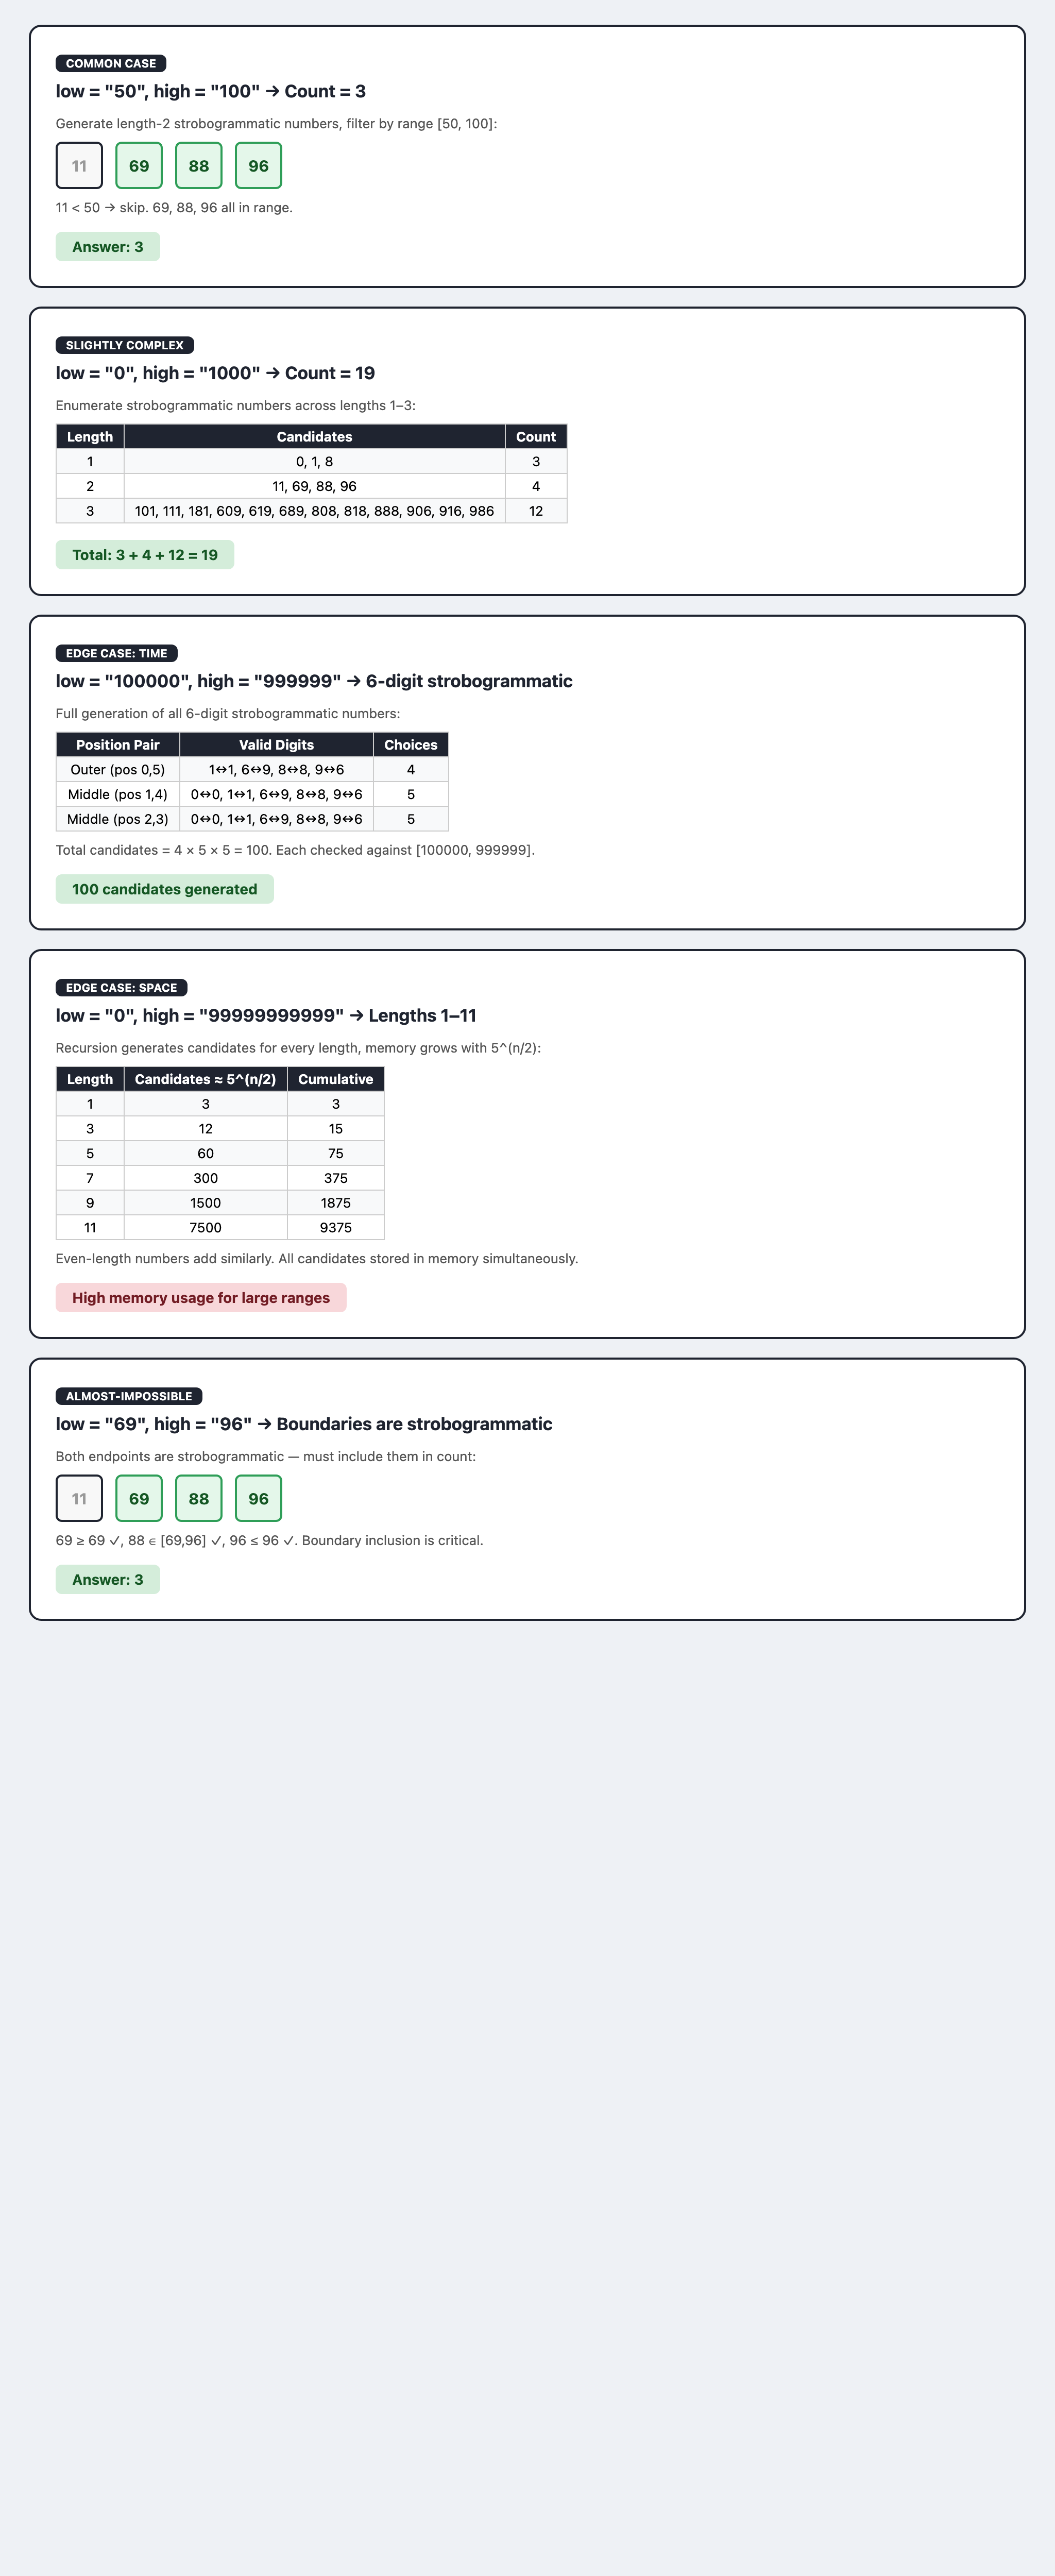